# Kalshi Series Inspection

This notebook loads `raw_series` from the Kalshi SQLite database and reproduces the current filtering logic from `kalshi_export/kalshi_registry/series_selection.py`.

It is designed as the series-level inspection notebook for the benchmark paper. Figures are saved into `artefacts/kalshi_plots`.


In [1]:
from __future__ import annotations

import sqlite3
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", None)


In [2]:
def find_repo_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "kalshi_export").exists() and (candidate / "db").exists():
            return candidate
    raise RuntimeError("Could not locate repository root from current working directory")


REPO_ROOT = find_repo_root(Path.cwd())
KALSHI_EXPORT_ROOT = REPO_ROOT / "kalshi_export"
DB_PATH = REPO_ROOT / "db" / "kalshi_probability_dataset.sqlite"
PLOTS_DIR = REPO_ROOT / "artefacts" / "kalshi_plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

for path in (REPO_ROOT, KALSHI_EXPORT_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

print(f"REPO_ROOT={REPO_ROOT}")
print(f"KALSHI_EXPORT_ROOT={KALSHI_EXPORT_ROOT}")
print(f"DB_PATH={DB_PATH}")
print(f"PLOTS_DIR={PLOTS_DIR}")


def save_plot(name: str) -> Path:
    path = PLOTS_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(path)
    return path


REPO_ROOT=/Users/sneddy/research/polymarket_research
KALSHI_EXPORT_ROOT=/Users/sneddy/research/polymarket_research/kalshi_export
DB_PATH=/Users/sneddy/research/polymarket_research/db/kalshi_probability_dataset.sqlite
PLOTS_DIR=/Users/sneddy/research/polymarket_research/artefacts/kalshi_plots


In [3]:
from kalshi_registry.series_selection import (
    ALLOWED_CATEGORIES,
    DENIED_FREQUENCIES,
    DENIED_TITLE_PATTERNS,
    _matches_any,
)

sorted(ALLOWED_CATEGORIES)


['Companies',
 'Economics',
 'Elections',
 'Entertainment',
 'Financials',
 'Health',
 'Politics',
 'Science and Technology',
 'Social',
 'World']

In [4]:
with sqlite3.connect(DB_PATH) as conn:
    raw_series = pd.read_sql_query("SELECT * FROM raw_series", conn)

print(f"raw_series={raw_series.shape}")
raw_series.head(3)


raw_series=(9721, 13)


,series_ticker,title,subtitle,category,tags_json,frequency,status,created_at,updated_at,close_time,settlement_time,raw_payload_json,synced_at_utc
0,POPVOTEDJTMO,Trump Missouri,None,Politics,"[""US Elections""]",one_off,None,None,2026-02-26T08:50:31.901806Z,None,None,"{""additional_prohibitions"": [""Holders of federal and statewide public office."", ""Paid campaign staffers on Presidential campaigns."", ""Anyone working in a vote-tallying capacity, or who has the potential ability to observe official vote counts before they are public."", ""Third-party vendors and contractors (and employees thereof) of Presidential campaigns."", ""Paid employees of Democratic and Republican Party organizations, such as the Democratic Congressional Campaign Committee or the Republican National Committee."", ""Paid employees of Political Action Committees (PACs) and “Super PACs” (independent expenditure only political committees)."", ""Paid employees of major polling organizations. "", ""Employees of Decision Desks at major media organizations."", ""All staff of the U.S. House of Representatives and its members."", ""All staff of the U.S. Senate and its members."", ""All staff of the Office of the President of the United States."", ""All staff of the Office of the Vice President of the United States."", ""All staff of the U.S. Supreme Court and its Justices."", ""Any foreign national. This is defined as an individual who is: (1) not a citizen of the United States and (2) not lawfully admitted for permanent residence (as defined in 8 U.S.C. § 1101(a)(20)); or a foreign principal, as defined in 22 U.S.C. § 611(b). Section 611(b) defines a foreign principal to include a foreign government or political party; or a partnership, association, corporation, organization, or other combination of persons organized under the laws of a foreign country or whose principal place of business is in a foreign country."", ""Persons who are employed by any of the Source Agencies are not permitted to trade on the Contract."", ""Persons who hold any material, non-public information on the Underlying are not permitted to trade on the Contract.""], ""category"": ""Politics"", ""contract_terms_url"": ""https://kalshi-public-docs.s3.amazonaws.com/contract_terms/POPVOTESTATEMOV.pdf"", ""contract_url"": ""https://kalshi-public-docs.s3.us-east-1.amazonaws.com/regulatory/product-certifications/POPVOTESTATEMOV.pdf"", ""fee_multiplier"": 1, ""fee_type"": ""quadratic"", ""frequency"": ""one_off"", ""last_updated_ts"": ""2026-02-26T08:50:31.901806Z"", ""settlement_sources"": [{""name"": ""United States Congress"", ""url"": ""https://www.congress.gov/""}], ""tags"": [""US Elections""], ""ticker"": ""POPVOTEDJTMO"", ""title"": ""Trump Missouri""}",2026-04-17T08:41:58Z
1,HURCHARL,Hurricane hits Charleston,None,Climate and Weather,"[""Hurricanes""]",custom,None,None,2026-02-26T08:50:31.901806Z,None,None,"{""additional_prohibitions"": [""Persons who are employed by any of the Source Agencies are not permitted to trade on the Contract."", ""Persons who hold any material, non-public information on the Underlying are not permitted to trade on the Contract.""], ""category"": ""Climate and Weather"", ""contract_terms_url"": ""https://kalshi-public-docs.s3.amazonaws.com/contract_terms/HURCHARL.pdf"", ""contract_url"": ""https://kalshi-public-docs.s3.us-east-1.amazonaws.com/regulatory/product-certifications/HURCHARL.pdf"", ""fee_multiplier"": 1, ""fee_type"": ""quadratic"", ""frequency"": ""custom"", ""last_updated_ts"": ""2026-02-26T08:50:31.901806Z"", ""settlement_sources"": [{""name"": ""National Weather Service (Charleston)"", ""url"": ""https://forecast.weather.gov/product.php?site=CHS&product=CLI&issuedby=CHS""}], ""tags"": [""Hurricanes""], ""ticker"": ""HURCHARL"", ""title"": ""Hurricane hits Charleston""}",2026-04-17T08:41:58Z
2,KXGA1ROUND,Which Georgia elections will be won outright?,None,Elections,"[""US Elections""]",one_off,None,None,2026-04-15T23:22:03.969788Z,None,None,"{""add

## Reproduce current `series_selection.py` logic

The masks below intentionally match the current script as implemented.


In [5]:
series_df = raw_series.copy()
series_df["category_norm"] = series_df["category"].fillna("").astype(str).str.strip()
series_df["frequency_norm"] = series_df["frequency"].fillna("").astype(str).str.strip().str.lower()
series_df["title_norm"] = series_df["title"].fillna("").astype(str)
series_df["subtitle_norm"] = series_df["subtitle"].fillna("").astype(str)
series_df["ticker_norm"] = series_df["series_ticker"].fillna("").astype(str)
series_df["tags_norm"] = series_df["tags_json"].fillna("").astype(str)
series_df["text_blob"] = series_df["title_norm"] + " " + series_df["subtitle_norm"] + " " + series_df["tags_norm"]
series_df.head(2)


,series_ticker,title,subtitle,category,tags_json,frequency,status,created_at,updated_at,close_time,settlement_time,raw_payload_json,synced_at_utc,category_norm,frequency_norm,title_norm,subtitle_norm,ticker_norm,tags_norm,text_blob
0,POPVOTEDJTMO,Trump Missouri,None,Politics,"[""US Elections""]",one_off,None,None,2026-02-26T08:50:31.901806Z,None,None,"{""additional_prohibitions"": [""Holders of federal and statewide public office."", ""Paid campaign staffers on Presidential campaigns."", ""Anyone working in a vote-tallying capacity, or who has the potential ability to observe official vote counts before they are public."", ""Third-party vendors and contractors (and employees thereof) of Presidential campaigns."", ""Paid employees of Democratic and Republican Party organizations, such as the Democratic Congressional Campaign Committee or the Republican National Committee."", ""Paid employees of Political Action Committees (PACs) and “Super PACs” (independent expenditure only political committees)."", ""Paid employees of major polling organizations. "", ""Employees of Decision Desks at major media organizations."", ""All staff of the U.S. House of Representatives and its members."", ""All staff of the U.S. Senate and its members."", ""All staff of the Office of the President of the United States."", ""All staff of the Office of the Vice President of the United States."", ""All staff of the U.S. Supreme Court and its Justices."", ""Any foreign national. This is defined as an individual who is: (1) not a citizen of the United States and (2) not lawfully admitted for permanent residence (as defined in 8 U.S.C. § 1101(a)(20)); or a foreign principal, as defined in 22 U.S.C. § 611(b). Section 611(b) defines a foreign principal to include a foreign government or political party; or a partnership, association, corporation, organization, or other combination of persons organized under the laws of a foreign country or whose principal place of business is in a foreign country."", ""Persons who are employed by any of the Source Agencies are not permitted to trade on the Contract."", ""Persons who hold any material, non-public information on the Underlying are not permitted to trade on the Contract.""], ""category"": ""Politics"", ""contract_terms_url"": ""https://kalshi-public-docs.s3.amazonaws.com/contract_terms/POPVOTESTATEMOV.pdf"", ""contract_url"": ""https://kalshi-public-docs.s3.us-east-1.amazonaws.com/regulatory/product-certifications/POPVOTESTATEMOV.pdf"", ""fee_multiplier"": 1, ""fee_type"": ""quadratic"", ""frequency"": ""one_off"", ""last_updated_ts"": ""2026-02-26T08:50:31.901806Z"", ""settlement_sources"": [{""name"": ""United States Congress"", ""url"": ""https://www.congress.gov/""}], ""tags"": [""US Elections""], ""ticker"": ""POPVOTEDJTMO"", ""title"": ""Trump Missouri""}",2026-04-17T08:41:58Z,Politics,one_off,Trump Missouri,,POPVOTEDJTMO,"[""US Elections""]","Trump Missouri [""US Elections""]"
1,HURCHARL,Hurricane hits Charleston,None,Climate and Weather,"[""Hurricanes""]",custom,None,None,2026-02-26T08:50:31.901806Z,None,None,"{""additional_prohibitions"": [""Persons who are employed by any of the Source Agencies are not permitted to trade on the Contract."", ""Persons who hold any material, non-public information on the Underlying are not permitted to trade on the Contract.""], ""category"": ""Climate and Weather"", ""contract_terms_url"": ""https://kalshi-public-docs.s3.amazonaws.com/contract_terms/HURCHARL.pdf"", ""contract_url"": ""https://kalshi-public-docs.s3.us-east-1.amazonaws.com/regulatory/product-certifications/HURCHARL.pdf"", ""fee_multiplier"": 1, ""fee_type"": ""quadratic"", ""frequency"": ""custom"", ""last_updated_ts"": ""2026-02-26T08:50:31.901806Z"", ""settlement_sources"": [{""name"": ""National Weather Service (Charleston)"", ""url"": ""https://forecast.weather.gov/product.php?site=CHS&product=CLI&issuedby=CHS""}], ""tags"": [""Hurricanes""], ""ticker"": ""HURCHARL"", ""title"": ""Hurricane hits Charl

In [6]:
series_df = raw_series.copy()
series_df["category_norm"] = series_df["category"].fillna("").astype(str).str.strip()
series_df["frequency_norm"] = series_df["frequency"].fillna("").astype(str).str.strip().str.lower()
series_df["title_norm"] = series_df["title"].fillna("").astype(str)
series_df["subtitle_norm"] = series_df["subtitle"].fillna("").astype(str)
series_df["ticker_norm"] = series_df["series_ticker"].fillna("").astype(str)
series_df["tags_norm"] = series_df["tags_json"].fillna("").astype(str)
series_df["text_blob"] = series_df["title_norm"] + " " + series_df["subtitle_norm"] + " " + series_df["tags_norm"]

series_df["pass_frequency"] = ~series_df["frequency_norm"].isin(DENIED_FREQUENCIES)
series_df["pass_category"] = series_df["category_norm"].isin(ALLOWED_CATEGORIES)
series_df["denied_by_title"] = series_df["text_blob"].map(lambda text: _matches_any(DENIED_TITLE_PATTERNS, text))

series_df["after_frequency"] = series_df["pass_frequency"]
series_df["after_category"] = series_df["after_frequency"] & series_df["pass_category"]
series_df["selected_by_script"] = series_df["after_category"] & ~series_df["denied_by_title"]

selected_df = series_df.loc[series_df["selected_by_script"]].copy()
selected_df[["series_ticker", "title", "category_norm", "frequency", "status"]].head(20)


,series_ticker,title,category_norm,frequency,status
0,POPVOTEDJTMO,Trump Missouri,Politics,one_off,None
2,KXGA1ROUND,Which Georgia elections will be won outright?,Elections,one_off,None
4,KXCLEANCR,Clean CR,Politics,custom,None
5,KXIRS,IRS Commissioner,Politics,custom,None
6,KXLLADEPUTIES,LLA deputies percentage vote,Elections,one_off,None
7,KXTHELASTOFUSS2,The Last of Us S2 RT,Entertainment,custom,None
9,KXVOTEDRFK,Dems for RFK,Politics,one_off,None
10,KXATTYGENOK,AG race OK,Elections,one_off,None
12,KXGEORGIAPARLI,Georgia parliamentary election,Elections,one_off,None
13,KXSENATEFLR,Florida Republican Senate nominee,Elections,custom,None


In [7]:
filter_counts = pd.DataFrame(
    {
        "stage": [
            "all raw_series",
            "after frequency filter",
            "after category filter",
            "after title deny",
        ],
        "rows": [
            len(series_df),
            int(series_df["after_frequency"].sum()),
            int(series_df["after_category"].sum()),
            int(series_df["selected_by_script"].sum()),
        ],
    }
)
filter_counts["pct_of_raw"] = (100.0 * filter_counts["rows"] / max(len(series_df), 1)).round(2)
filter_counts["dropped_this_step"] = filter_counts["rows"].shift(1, fill_value=filter_counts.loc[0, "rows"]) - filter_counts["rows"]
filter_counts


,stage,rows,pct_of_raw,dropped_this_step
0,all raw_series,9721,100.00,0
1,after frequency filter,9487,97.59,234
2,after category filter,6905,71.03,2582
3,after title deny,6225,64.04,680


/Users/sneddy/research/polymarket_research/artefacts/kalshi_plots/kalshi_series_selection_funnel.png


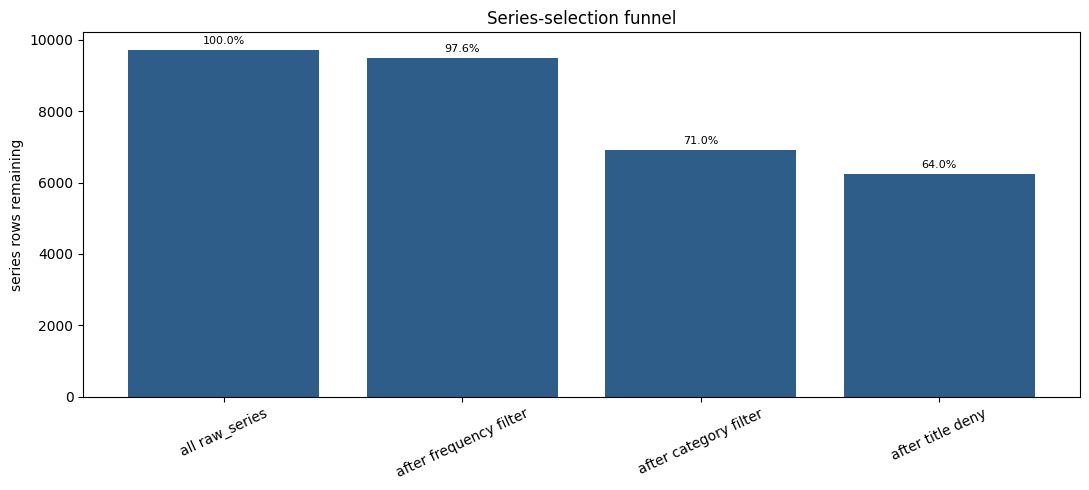

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(filter_counts["stage"], filter_counts["rows"], color="#2f5d8a")
ax.set_title("Series-selection funnel")
ax.set_ylabel("series rows remaining")
ax.tick_params(axis="x", rotation=25)

for bar, pct in zip(bars, filter_counts["pct_of_raw"]):
    height = bar.get_height()
    ax.annotate(
        f"{pct:.1f}%",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
    )

save_plot("kalshi_series_selection_funnel.png")
plt.show()


In [9]:
category_counts = (
    series_df.groupby("category_norm", dropna=False)
    .size()
    .reset_index(name="series_count")
    .sort_values("series_count", ascending=False)
)
category_counts.head(20)


,category_norm,series_count
8,Entertainment,2358
13,Politics,1827
16,Sports,1739
7,Elections,1262
5,Economics,509
3,Companies,351
12,Mentions,336
1,Climate and Weather,269
4,Crypto,225
14,Science and Technology,203


/Users/sneddy/research/polymarket_research/artefacts/kalshi_plots/kalshi_raw_series_top_categories.png


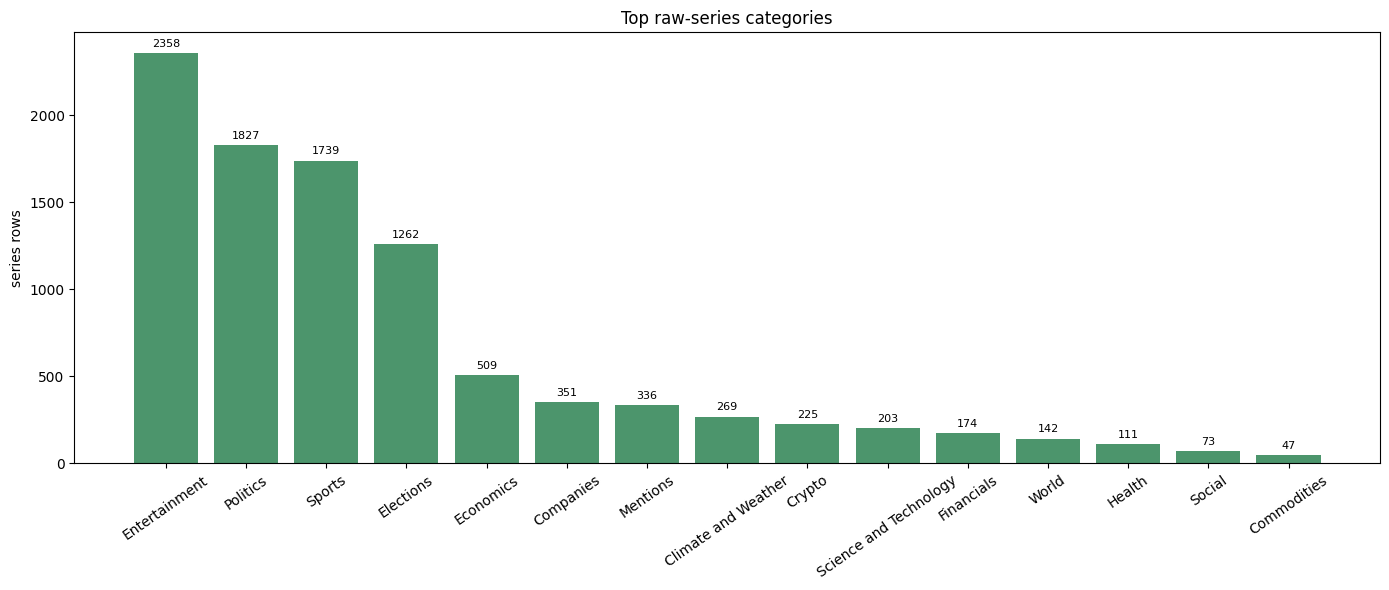

In [10]:
plot_categories = category_counts.head(15).copy()
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(plot_categories["category_norm"], plot_categories["series_count"], color="#4c956c")
ax.set_title("Top raw-series categories")
ax.set_ylabel("series rows")
ax.tick_params(axis="x", rotation=35)

for bar in bars:
    height = int(bar.get_height())
    ax.annotate(
        f"{height}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
    )

save_plot("kalshi_raw_series_top_categories.png")
plt.show()


## Category comparison before and after selection


In [11]:
raw_series_category_counts = (
    series_df.groupby("category_norm", dropna=False)
    .size()
    .reset_index(name="raw_series_rows")
)

selected_series_category_counts = (
    selected_df.groupby("category_norm", dropna=False)
    .size()
    .reset_index(name="selected_series_rows")
)

category_compare = (
    raw_series_category_counts.merge(selected_series_category_counts, on="category_norm", how="outer")
    .fillna(0)
)
category_compare[["raw_series_rows", "selected_series_rows"]] = category_compare[["raw_series_rows", "selected_series_rows"]].astype(int)
category_compare["selection_rate_pct"] = (
    100.0 * category_compare["selected_series_rows"] / category_compare["raw_series_rows"].replace({0: np.nan})
).round(2)
category_compare = category_compare.sort_values("raw_series_rows", ascending=False)
category_compare.head(20)


,category_norm,raw_series_rows,selected_series_rows,selection_rate_pct
8,Entertainment,2358,1778,75.40
13,Politics,1827,1804,98.74
16,Sports,1739,0,0.00
7,Elections,1262,1261,99.92
5,Economics,509,444,87.23
3,Companies,351,347,98.86
12,Mentions,336,0,0.00
1,Climate and Weather,269,0,0.00
4,Crypto,225,0,0.00
14,Science and Technology,203,195,96.06


/Users/sneddy/research/polymarket_research/artefacts/kalshi_plots/kalshi_series_categories_before_after.png


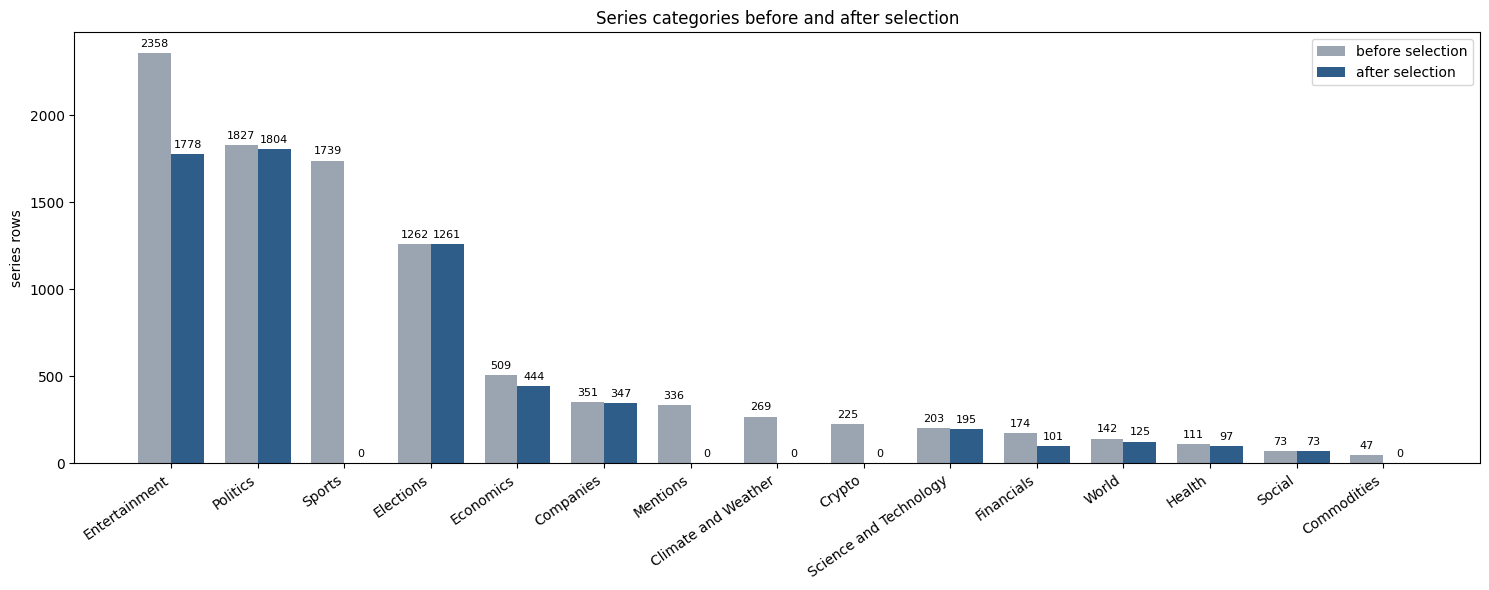

In [12]:
plot_categories = category_compare.head(15).copy()
x = np.arange(len(plot_categories))
width = 0.38

fig, ax = plt.subplots(figsize=(15, 6))
bars1 = ax.bar(x - width / 2, plot_categories["raw_series_rows"], width, label="before selection", color="#9aa5b1")
bars2 = ax.bar(x + width / 2, plot_categories["selected_series_rows"], width, label="after selection", color="#2f5d8a")
ax.set_title("Series categories before and after selection")
ax.set_ylabel("series rows")
ax.set_xticks(x)
ax.set_xticklabels(plot_categories["category_norm"], rotation=35, ha="right")
ax.legend()

for bars in (bars1, bars2):
    for bar in bars:
        height = int(bar.get_height())
        ax.annotate(
            f"{height}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
        )

save_plot("kalshi_series_categories_before_after.png")
plt.show()


/Users/sneddy/research/polymarket_research/artefacts/kalshi_plots/kalshi_series_selection_rate_by_category.png


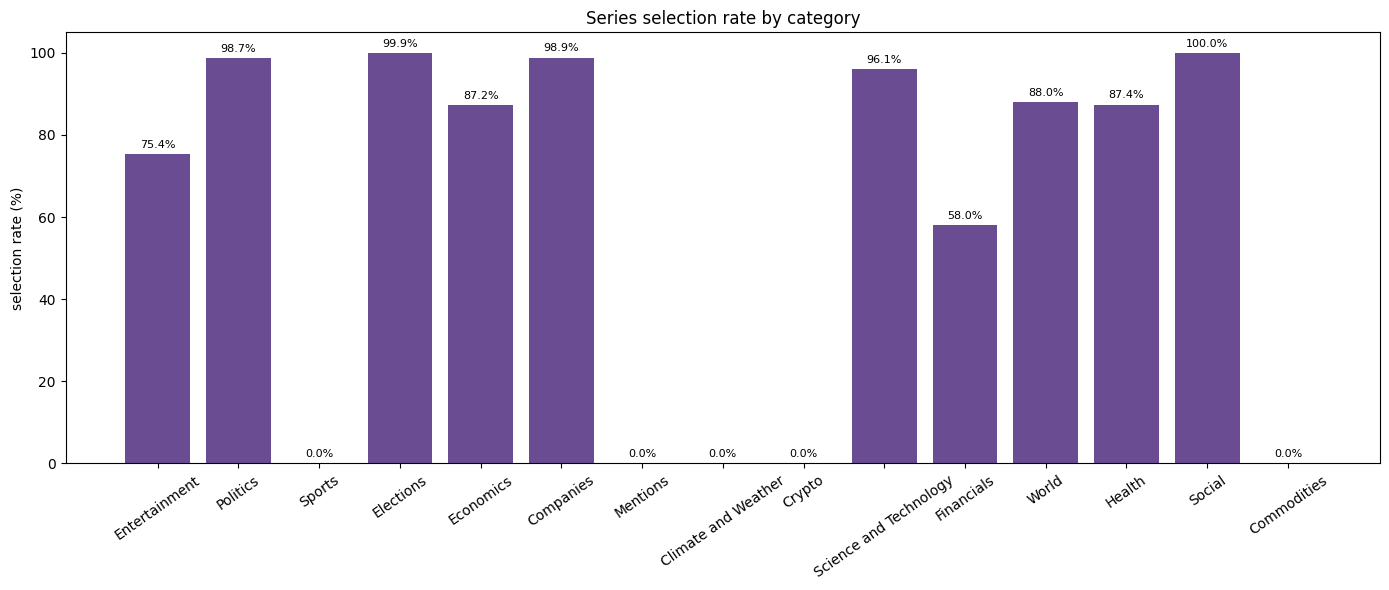

In [13]:
plot_rate = category_compare.head(15).copy()
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(plot_rate["category_norm"], plot_rate["selection_rate_pct"].fillna(0), color="#6a4c93")
ax.set_title("Series selection rate by category")
ax.set_ylabel("selection rate (%)")
ax.tick_params(axis="x", rotation=35)

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height:.1f}%",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
    )

save_plot("kalshi_series_selection_rate_by_category.png")
plt.show()


In [14]:
frequency_compare = (
    series_df.groupby(series_df["frequency"].fillna(""), dropna=False)
    .size()
    .reset_index(name="raw_series_rows")
    .rename(columns={"frequency": "frequency_norm"})
    .merge(
        selected_df.groupby(selected_df["frequency"].fillna(""), dropna=False)
        .size()
        .reset_index(name="selected_series_rows")
        .rename(columns={"frequency": "frequency_norm"}),
        on="frequency_norm",
        how="outer",
    )
    .fillna(0)
)
frequency_compare[["raw_series_rows", "selected_series_rows"]] = frequency_compare[["raw_series_rows", "selected_series_rows"]].astype(int)
frequency_compare = frequency_compare.sort_values("raw_series_rows", ascending=False)
frequency_compare


,frequency_norm,raw_series_rows,selected_series_rows
1,custom,3977,2415
6,one_off,3848,2972
0,annual,1225,608
5,monthly,261,138
2,daily,191,0
7,weekly,176,92
4,hourly,34,0
3,fifteen_min,9,0


In [15]:
raw_series.frequency.value_counts()

frequency
custom         3977
one_off        3848
annual         1225
monthly         261
daily           191
weekly          176
hourly           34
fifteen_min       9
Name: count, dtype: int64

/Users/sneddy/research/polymarket_research/artefacts/kalshi_plots/kalshi_series_frequency_before_after.png


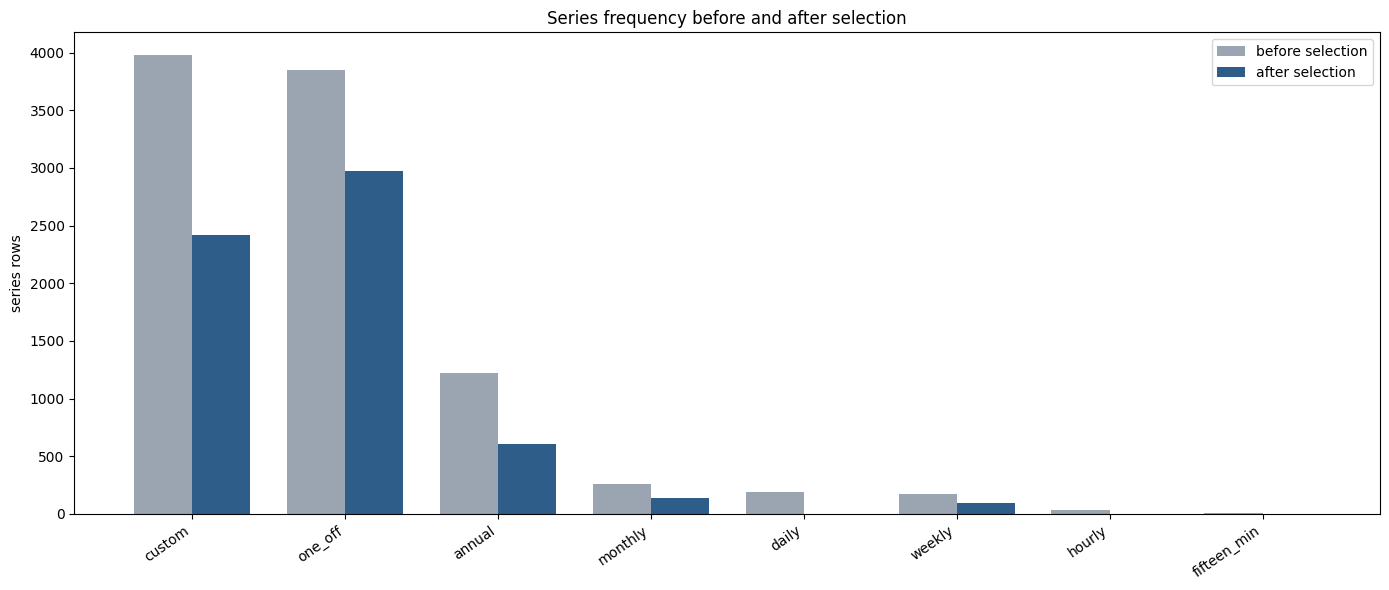

In [16]:
plot_frequency = frequency_compare.head(12).copy()
x = np.arange(len(plot_frequency))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width / 2, plot_frequency["raw_series_rows"], width, label="before selection", color="#9aa5b1")
ax.bar(x + width / 2, plot_frequency["selected_series_rows"], width, label="after selection", color="#2f5d8a")
ax.set_title("Series frequency before and after selection")
ax.set_ylabel("series rows")
ax.set_xticks(x)
ax.set_xticklabels(plot_frequency["frequency_norm"], rotation=35, ha="right")
ax.legend()
save_plot("kalshi_series_frequency_before_after.png")
plt.show()


In [17]:
deny_summary = pd.DataFrame(
    {
        "reason": [
            "frequency removed",
            "fails category allowlist",
            "denied by title patterns",
        ],
        "rows": [
            int((~series_df["pass_frequency"]).sum()),
            int((series_df["after_frequency"] & ~series_df["pass_category"]).sum()),
            int((series_df["after_category"] & series_df["denied_by_title"]).sum()),
        ],
    }
)
deny_summary


,reason,rows
0,frequency removed,234
1,fails category allowlist,2582
2,denied by title patterns,680


/Users/sneddy/research/polymarket_research/artefacts/kalshi_plots/kalshi_series_deny_rule_counts.png


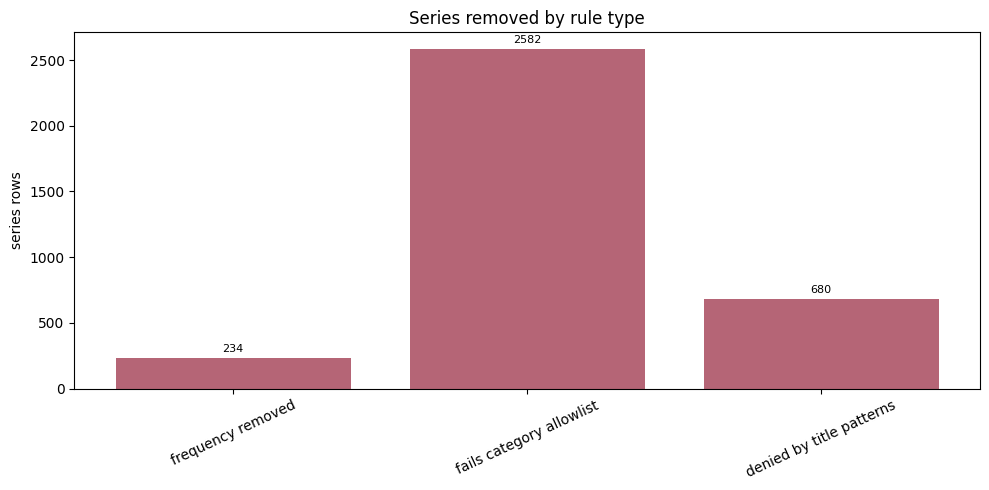

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(deny_summary["reason"], deny_summary["rows"], color="#b56576")
ax.set_title("Series removed by rule type")
ax.set_ylabel("series rows")
ax.tick_params(axis="x", rotation=25)

for bar in bars:
    height = int(bar.get_height())
    ax.annotate(
        f"{height}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
    )

save_plot("kalshi_series_deny_rule_counts.png")
plt.show()


## Sample series dropped at each stage

This cell samples the series that are removed by each stage of `series_selection` in order.


In [19]:
drop_samples = {
    "dropped_by_frequency": series_df.loc[
        ~series_df["pass_frequency"],
        ["series_ticker", "title", "category_norm", "frequency", "tags_norm"],
    ].sample(n=min(10, int((~series_df["pass_frequency"]).sum())), random_state=7) if int((~series_df["pass_frequency"]).sum()) else pd.DataFrame(),
    "dropped_by_category": series_df.loc[
        series_df["after_frequency"] & ~series_df["pass_category"],
        ["series_ticker", "title", "category_norm", "frequency", "tags_norm"],
    ].sample(n=min(10, int((series_df["after_frequency"] & ~series_df["pass_category"]).sum())), random_state=7) if int((series_df["after_frequency"] & ~series_df["pass_category"]).sum()) else pd.DataFrame(),
    "dropped_by_title_patterns": series_df.loc[
        series_df["after_category"] & series_df["denied_by_title"],
        ["series_ticker", "title", "category_norm", "frequency", "tags_norm"],
    ].sample(n=min(10, int((series_df["after_category"] & series_df["denied_by_title"]).sum())), random_state=7) if int((series_df["after_category"] & series_df["denied_by_title"]).sum()) else pd.DataFrame(),
}

for stage_name, sample_df in drop_samples.items():
    print(f"\n=== {stage_name} ===")
    display(sample_df)



=== dropped_by_frequency ===


,series_ticker,title,category_norm,frequency,tags_norm
6241,KXGBP,British Pound/US Dollar exchange rate,Financials,daily,
3426,KXSPOTIFYCOSTARICAD,Daily COSTA RICA Spotify songs,Entertainment,daily,"[""Music"", ""Music charts""]"
3744,KXLOWTDAL,Lowest temperature Dallas,Climate and Weather,daily,"[""Daily temperature""]"
8520,KXLOWDEN,Lowest temperature in Denver,Climate and Weather,daily,
190,KXBNB15M,BNB 15 Minute,Crypto,fifteen_min,"[""BNB"", ""15 min""]"
3795,KXSOLDATHOLDINGS,SOL Dat Holdings,Crypto,daily,"[""SOL""]"
4353,KXJPY,U.S. Dollar/Japanese yen exchange rate,Economics,daily,
643,KXDOGE,Dogecoin range,Crypto,hourly,"[""Hourly"", ""DOGE""]"
6285,ETH,Ethereum range,Crypto,daily,"[""ETH""]"
3616,KXSPOTIFYSONGSMANOFTHEYEAR,TOTAL SPOTIFY STREAMS FOR LORDES MAN OF THE YEAR,Entertainment,daily,"[""Music""]"



=== dropped_by_category ===


,series_ticker,title,category_norm,frequency,tags_norm
872,KXWCGAME,World Cup Game,Sports,custom,"[""Soccer""]"
7690,KXNFLGAMESACK,Pro Football Sacks,Sports,custom,"[""Football""]"
5350,KXHURSAV,Hurricane hits Savannah,Climate and Weather,custom,"[""Hurricanes""]"
2781,KXHURCMAJ,Number of major hurricanes,Climate and Weather,custom,"[""Hurricanes"", ""Natural disasters""]"
3149,KXMCGREGORFIGHTNEXT,McGregor fight next,Sports,one_off,"[""MMA""]"
4821,KXCSGOGAME,Counter-Strike 2 Games,Sports,custom,"[""Esports""]"
8224,KXNCAAMBPAT,Patriot League Conference Tournament,Sports,custom,"[""Basketball""]"
5742,KXCOACHOUTDALWINGS,Chris Koclanes out,Sports,custom,
2318,KXEFLCHAMPIONSHIPGAME,EFL Championship Game,Sports,custom,"[""Soccer""]"
6888,KXEWSLGAME,England Women's Super League Game,Sports,custom,"[""Soccer""]"



=== dropped_by_title_patterns ===


,series_ticker,title,category_norm,frequency,tags_norm
6567,KXMCSILENTHILL2,Silent Hill 2 Metacritic scores,Entertainment,custom,"[""Video games""]"
2769,KXRTX5090W,RTX 5090 Weekly Price,Science and Technology,weekly,"[""Energy"", ""AI""]"
7466,METACRITICSTALKER2,Metacritic scores,Entertainment,custom,"[""Video games""]"
194,KXSPOTIFYSONGSKILLINGITGIRL,How many streams will Killin' It Girl (feat. GloRilla)get in its first week,Entertainment,weekly,"[""Music""]"
5996,KXRTTRONARES,Tron Ares Rotten Tomatoes score,Entertainment,custom,"[""Movies"", ""Rotten Tomatoes""]"
3233,MCDAWNTRAIL,Metacritic scores,Entertainment,custom,"[""Video games""]"
2534,KXIMALITTLECRAZY,total streams,Entertainment,custom,"[""Morgan Wallen"", ""Music Streams""]"
680,USDRUBMIN,USD/RUB yearly low,Financials,custom,"[""USD/RUB""]"
7305,KXSPOTIFYSONGSSTATESIDE,How many total streams will Stateside get?,Entertainment,custom,"[""Music""]"
3649,KXTRUMPPOLLDAILY,What will Trump's approval rating be today?,Politics,one_off,"[""Recurring""]"


In [20]:
series_df.loc[series_df["after_category"] & series_df["denied_by_title"],
        ["series_ticker", "title", "category_norm", "frequency", "tags_norm"],
    ].sample(20).title

6539                     Den of Thieves Rotten Tomatoes score
53                   Total streams for Lordes man of the year
2038                               Trap Rotten Tomatoes Score
944                                     Spotify album streams
9292                           How many streams will Opalite 
6475           Will song receive a billion streams on spotify
2523               Bad Boys Ride or Die Rotten Tomatoes score
7462                                        Metacritic scores
404                       Most Streamed song on Deep Thoughts
7520                          Good Luck, Babe! Billboard Peak
129                      NY (ex NYC) COVID daily case average
5887                             Reagan Rotten Tomatoes score
4563                                   Chihiro Billboard Peak
5570                                   Don’t We total streams
7881                                    Rotten Tomatoes score
6441                Quiet Place Day One Rotten Tomatoes score
7309    

In [21]:
selected_df[["series_ticker", "title", "category_norm", "frequency"]].head(20)


,series_ticker,title,category_norm,frequency
0,POPVOTEDJTMO,Trump Missouri,Politics,one_off
2,KXGA1ROUND,Which Georgia elections will be won outright?,Elections,one_off
4,KXCLEANCR,Clean CR,Politics,custom
5,KXIRS,IRS Commissioner,Politics,custom
6,KXLLADEPUTIES,LLA deputies percentage vote,Elections,one_off
7,KXTHELASTOFUSS2,The Last of Us S2 RT,Entertainment,custom
9,KXVOTEDRFK,Dems for RFK,Politics,one_off
10,KXATTYGENOK,AG race OK,Elections,one_off
12,KXGEORGIAPARLI,Georgia parliamentary election,Elections,one_off
13,KXSENATEFLR,Florida Republican Senate nominee,Elections,custom


In [22]:
selected_df[selected_df["title"].str.contains("viewership", case=False, na=False)].title


6516              SB viewership
8304          Oscars viewership
8659    Inauguration viewership
Name: title, dtype: str

In [25]:
selected_df.sample(40).title.values.tolist()

['WHEN WILL TAYLOR SWIFT RELEASE AN ALBUM',
 'Nebraska Senate special election',
 'What position will song/album be on the Billboard chart?',
 'Will Defying Gravity re-enter the Billboard Hot 100 for the week of December __?',
 'zz',
 'Who will be featured on kany west album',
 'Will destroy lonely havea #1 album this year',
 'NYT WH ban',
 'TIME’s Person of the Year',
 'HOw many spotify streams will maroon 5 adam levine all night get ',
 'Powell confirmation',
 'Will Americans receive tariff dividends in 2025?',
 'Will Young Thug Release an album?',
 'Nobel Economics prize',
 'WHO WILL BE FEATURED ON KENDRICK LAMARS NEXT ALBUM',
 'WILL Haliey Welch BE ARRESTED',
 'Oscar for Best Sound',
 'IRA cuts',
 'Eurovision participants',
 'Bill limiting food SNAP benefits can buy',
 'TITLE',
 'Top media by platform?',
 'WILL THE AVENGERS BE DELAYED',
 'Forever Is a Feeling review',
 'How many receipts will Brian Baumgartner process in 8 hours?',
 'Tennessee Governor',
 'Gigi Sohn FCC confirmatio

In [31]:
selected_df[selected_df.category == 'Entertainment'].title.sample(40).tolist()

['KENDRICK LAMAR Grammy wins',
 'Oscar for Best Director',
 'Favorite Afrobeats Artist',
 'How many songs will justin bieber have on the bilboard 100 top 10 chart',
 'BEST WNBA PLAYER\u202c\u202d',
 'Usher Top Album',
 'Will “The Summer I Turned Pretty” release a movie ',
 'Top media by platform?',
 '\u202dBEST CHAMPIONSHIP PERFORMANCE\u202c',
 'Emmys Award for Drama Series',
 'Will person perform at Coachella ',
 'WHO WILL BE ON THE COVER OF NBA 2K',
 "who will attend Dick Cheney's funeral",
 'What genre will taylor swifts album be',
 'KENDRICK LAMAR #1 Album',
 'ANIMATED SHORT FILM',
 'Avatar season two announcement',
 'elon on joe rogan',
 'Post Malone #1 Album',
 'Billboard Top 20 artists',
 'Album of the Year',
 'WILL DRAKE AND METRO BOOMIN MAKE A SONG TOGETHER THIS YEAR',
 'Emmy for Movie/Limited Supporting Actress',
 'Least streamed song on  Honkytonk Hollywood',
 'Grammys delayed',
 'Tate Mcrae that kid laroi make a song together',
 'How many of the top 10 spots will Morgan Wal

In [24]:
selected_df.frequency.value_counts()

frequency
one_off    2972
custom     2415
annual      608
monthly     138
weekly       92
Name: count, dtype: int64